# Defining Mode Sources and Monitors in BEAMZ

This notebook mirrors the Tidy3D `ModalSourcesMonitors.ipynb` example with the local `beamz-1/matplotlib` implementation. We launch a broadband fundamental mode of a silicon waveguide, record fields on monitor planes, decompose the output into guided modes, and then repeat the calculation for a width-step junction.

The implementation is intentionally close to the original tutorial, but uses BEAMZ concepts:

- `ModeSource` computes guided-mode profiles on the source plane and injects them into the FDTD grid.
- `Monitor` objects accumulate frequency-domain DFT fields on transverse planes.
- `PortSpec` tells BEAMZ how to project those monitor fields onto forward and backward waveguide modes.
- `Simulation.get_S_matrix_modal_dft(...)` returns modal amplitudes and normalized power spectra.

Current BEAMZ note: this notebook keeps the Tidy3D-style workflow, but uses thicker 1.75 µm PMLs because the local PML is currently less mature.


## Setup

The notebook imports BEAMZ from the sibling `beamz-1` checkout when that directory is present, so it uses the local `matplotlib` branch rather than an installed package from elsewhere.


In [1]:
from pathlib import Path
import inspect
import sys

local_beamz = None
for candidate in (
    Path.cwd().resolve().parent / "beamz-1",
    Path.cwd().resolve().parent.parent / "beamz-1",
):
    if (candidate / "beamz").is_dir():
        local_beamz = candidate.resolve()
        break
if local_beamz is None:
    raise RuntimeError("Could not find local BEAMZ checkout at ../beamz-1 or ../../beamz-1")
sys.path = [str(local_beamz)] + [p for p in sys.path if p and Path(p).resolve() != local_beamz]
for name in list(sys.modules):
    if name == "beamz" or name.startswith("beamz."):
        del sys.modules[name]

import beamz
from beamz.simulation.core import Simulation
print(f"Using local BEAMZ checkout: {local_beamz}")
print(beamz.__file__)
print(inspect.getfile(Simulation))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from beamz import (
    LIGHT_SPEED,
    PML,
    Design,
    Material,
    ModeSource,
    Monitor,
    PortSpec,
    Rectangle,
    Simulation,
    calc_optimal_fdtd_params,
    plot_tidy3d_cross_sections,
    plot_tidy3d_dft_field,
    plot_mode_fields,
    µm,
)
from beamz.devices.sources.signals import gaussian_band_pulse

plt.rcParams.update({"figure.dpi": 120})


Using local BEAMZ checkout: /Users/quentinwach/Code/beamz-1
/Users/quentinwach/Code/beamz-1/beamz/__init__.py
/Users/quentinwach/Code/beamz-1/beamz/simulation/core.py


## Straight Waveguide Simulation

The Tidy3D example is a 3D silicon ridge waveguide on silicon dioxide. We use the same physical dimensions and place the geometry in BEAMZ's positive-coordinate design box. The FDTD mesh is deliberately coarser than the Tidy3D cloud example so it remains practical to run locally.


In [2]:
# Geometry and material parameters.
WG_HEIGHT = 0.22 * µm
WG_WIDTH = 0.45 * µm
SI_EPS = 3.48**2
SIO2_EPS = 1.45**2
AIR_EPS = 1.0
N_SI = np.sqrt(SI_EPS)
N_SIO2 = np.sqrt(SIO2_EPS)

# Optical band.
WL0 = 1.55 * µm
FREQ0 = LIGHT_SPEED / WL0
FWIDTH = FREQ0 / 10
NFREQS = 17
FREQS = np.linspace(FREQ0 - 2 * FWIDTH, FREQ0 + 2 * FWIDTH, NFREQS)
LAMBDAS_UM = LIGHT_SPEED / FREQS / µm
FCENT_IND = NFREQS // 2
SOURCE_PROFILE_FREQS = FREQS

# Use BEAMZ's broadband mode injection: one source profile per sampled frequency.
SOURCE_PROFILE_STRATEGY = "multifrequency"
MODAL_DFT_MODE_STRATEGY = "per_frequency"

# CPML is closer to Tidy3D PML behavior, but is several times slower than the
# simple sponge absorber in this local 3D implementation. Use "sponge" for
# fast plotting iterations and "cpml" for cleaner modal diagnostics.
PML_FORMULATION = "cpml"
PML_T = 1.75 * µm
PML_CLEARANCE = 0.5 * µm

# Simulation box and modal planes. Dimensions are in meters. BEAMZ includes
# the PML in the simulation domain, so keep the original usable interior spans
# while increasing the absorber thickness.
SIM_X = 4.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SIM_Y = 3.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SIM_Z = 2.0 * µm + 2.0 * (PML_T + PML_CLEARANCE)
SUBSTRATE_TOP_Z = 0.5 * SIM_Z
SUBSTRATE_T = SUBSTRATE_TOP_Z
WG_Z0 = SUBSTRATE_TOP_Z
WG_CENTER_Z = WG_Z0 + 0.5 * WG_HEIGHT

SRC_X = PML_T + PML_CLEARANCE
SRC_MON_X = SRC_X + 0.25 * µm
OUT_X = SIM_X - PML_T - PML_CLEARANCE
MODE_SPAN_Y = 3.0 * µm
MODE_SPAN_Z = 2.0 * µm
DEVICE_SPAN_Y = MODE_SPAN_Y
DEVICE_SPAN_Z = MODE_SPAN_Z
if SIM_Y < DEVICE_SPAN_Y + 2.0 * (PML_T + PML_CLEARANCE) or SIM_Z < DEVICE_SPAN_Z + 2.0 * (PML_T + PML_CLEARANCE):
    raise ValueError("Simulation domain is too small for the requested PML clearance.")
SOURCE_SPAN_Y = DEVICE_SPAN_Y
SOURCE_SPAN_Z = DEVICE_SPAN_Z
MONITOR_SPAN_Y = DEVICE_SPAN_Y
MONITOR_SPAN_Z = DEVICE_SPAN_Z

# Keep this modest for local execution; increase to 10-12 for better quantitative accuracy.
POINTS_PER_WAVELENGTH = 8 # 8 is nice for fast iterations, 14 already gives us darn nice results! 20 for perfect match
POLARIZATION = "te"
FIELD_COMPONENT = "Ey" if POLARIZATION == "te" else "Ez"
DISPLAY_FIELD_COMPONENT = FIELD_COMPONENT
DX, DT = calc_optimal_fdtd_params(
    WL0,
    N_SI,
    dims=3,
    safety_factor=0.999,
    points_per_wavelength=POINTS_PER_WAVELENGTH,
    width=SIM_X,
    height=SIM_Y,
    depth=SIM_Z,
)

print(f"dx = {DX/µm:.3f} um, dt = {DT*1e18:.2f} as")
print(f"grid shape approximately: {SIM_X/DX:.0f} x {SIM_Y/DX:.0f} x {SIM_Z/DX:.0f}")


dx = 0.056 um, dt = 107.11 as
grid shape approximately: 153 x 135 x 117


## Build the Structures

The straight guide is silicon on a silica substrate with air above. A second helper adds the wider output section used later for the mode-conversion junction.


In [3]:
def straight_waveguide_design():
    design = Design(
        width=SIM_X,
        height=SIM_Y,
        depth=SIM_Z,
        material=Material(AIR_EPS),
    )
    design += Rectangle(
        position=(0.0, 0.0, 0.0),
        width=SIM_X,
        height=SIM_Y,
        depth=SUBSTRATE_T,
        material=Material(SIO2_EPS),
    )
    design += Rectangle(
        position=(0.0, 0.5 * SIM_Y - 0.5 * WG_WIDTH, WG_Z0),
        width=SIM_X,
        height=WG_WIDTH,
        depth=WG_HEIGHT,
        material=Material(SI_EPS),
    )
    return design


def junction_design(wgout_width=1.4 * µm):
    design = straight_waveguide_design()
    design += Rectangle(
        position=(0.5 * SIM_X, 0.5 * SIM_Y - 0.5 * wgout_width, WG_Z0),
        width=0.5 * SIM_X,
        height=wgout_width,
        depth=WG_HEIGHT,
        material=Material(SI_EPS),
    )
    return design


design = straight_waveguide_design()
grid = design.rasterize(resolution=DX)


● Done: Raster cache hit (3d): ae5cfa6843a4f5d0b8be3956eb12336213610e6329b0e397a95736112fa72372.npz | load=0.55s


## Source and Monitor Helpers

BEAMZ modal S-parameter extraction uses ordinary DFT monitors plus `PortSpec` metadata. For a `+x` launch, BEAMZ's current port basis reports the forward-propagating output wave on the `a_minus` branch when the output `PortSpec.direction` is `+x`; the notebook helpers below keep that convention local and label the plots in physical terms.


In [4]:
def mode_window():
    y0 = 0.5 * SIM_Y - 0.5 * MODE_SPAN_Y
    y1 = 0.5 * SIM_Y + 0.5 * MODE_SPAN_Y
    z0 = WG_Z0 - 0.5 * MODE_SPAN_Z
    z1 = WG_Z0 + 0.5 * MODE_SPAN_Z
    return y0, y1, max(0.0, z0), min(SIM_Z, z1)


def device_window():
    y0 = 0.5 * SIM_Y - 0.5 * MONITOR_SPAN_Y
    y1 = 0.5 * SIM_Y + 0.5 * MONITOR_SPAN_Y
    z0 = WG_Z0 - 0.5 * MONITOR_SPAN_Z
    z1 = WG_Z0 + 0.5 * MONITOR_SPAN_Z
    return (
        max(PML_T + PML_CLEARANCE, y0),
        min(SIM_Y - PML_T - PML_CLEARANCE, y1),
        max(PML_T + PML_CLEARANCE, z0),
        min(SIM_Z - PML_T - PML_CLEARANCE, z1),
    )


def make_pulse():
    return gaussian_band_pulse(
        FREQS,
        carrier_frequency=FREQ0,
        dt=DT,
        run_after_sources_uoc=25.0,
        max_output_distance_um=(OUT_X - SRC_X) / µm,
    )


def source_profile_frequencies(strategy=None):
    strategy = SOURCE_PROFILE_STRATEGY if strategy is None else strategy
    if isinstance(strategy, str):
        key = strategy.lower()
        if key in {"center", "single", "single_frequency", "none"}:
            return None
        if key in {"multifrequency", "multi", "per_frequency", "per-frequency"}:
            return np.asarray(SOURCE_PROFILE_FREQS, dtype=float)
        raise ValueError(f"Unknown source profile strategy: {strategy!r}")
    if strategy is None:
        return None
    freqs = np.asarray(strategy, dtype=float).reshape(-1)
    return freqs if freqs.size > 1 else None


def make_source(grid, pulse, *, source_profile_strategy=None):
    return ModeSource(
        grid=grid,
        center=(SRC_X, 0.5 * SIM_Y, WG_Z0),
        width=SOURCE_SPAN_Y,
        height=SOURCE_SPAN_Z,
        wavelength=WL0,
        pol=POLARIZATION,
        signal=pulse.signal,
        signal_quadrature=pulse.signal_quadrature,
        profile_frequencies=source_profile_frequencies(source_profile_strategy),
        direction="+x",
    )


def dft_monitor(name, x, freqs=FREQS, record_fields=False):
    y0, y1, z0, z1 = device_window()
    return Monitor(
        start=(x, y0, z0),
        end=(x, y1, z1),
        name=name,
        record_fields=record_fields,
        accumulate_power=False,
        dft_enabled=True,
        dft_frequencies=np.asarray(freqs, dtype=float),
        dft_components=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
        dft_window="none",
        dft_record_every_step=True,
    )


def field_monitor(name="field"):
    return Monitor(
        start=(0.0, 0.0, WG_CENTER_Z),
        end=(SIM_X, SIM_Y, WG_CENTER_Z),
        name=name,
        record_fields=False,
        accumulate_power=False,
        dft_enabled=True,
        dft_frequencies=np.asarray([FREQ0], dtype=float),
        dft_components=(FIELD_COMPONENT,),
        dft_window="none",
        dft_record_every_step=True,
    )


def build_simulation(design, *, source_profile_strategy=None):
    grid = design.rasterize(resolution=DX)
    pulse = make_pulse()
    source = make_source(grid, pulse, source_profile_strategy=source_profile_strategy)
    monitors = [
        dft_monitor("src_ref", SRC_X),
        dft_monitor("src", SRC_MON_X),
        dft_monitor("out", OUT_X),
        field_monitor(),
    ]
    sim = Simulation(
        design=design,
        sources=[source],
        monitors=monitors,
        boundaries=[PML(edges="all", thickness=PML_T, formulation=PML_FORMULATION)],
        time=pulse.time,
        resolution=DX,
    )
    return sim, source, monitors, pulse


def modal_output_ports(num_modes=3):
    return [f"out_m{idx}" for idx in range(num_modes)]


def modal_ports(num_modes=3):
    ports = [
        PortSpec(
            name="src",
            monitor_name="src",
            reference_monitor="src_ref",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=0,
            incident_wave="auto",
            scattered_wave="auto",
        )
    ]
    ports.extend(
        PortSpec(
            name=f"out_m{idx}",
            monitor_name="out",
            direction="+x",
            polarization=POLARIZATION,
            mode_index=idx,
            incident_wave="plus",
            scattered_wave="minus",
        )
        for idx in range(num_modes)
    )
    return ports


def compute_modal_dft_result(sim, *, num_modes=3):
    return sim.get_S_matrix_modal_dft(
        source_port="src",
        ports=modal_ports(num_modes=num_modes),
        output_ports=["src", *modal_output_ports(num_modes)],
        frequencies=FREQS,
        as_sax=False,
        return_diagnostics=True,
        min_incident_db=-50.0,
        mode_strategy=MODAL_DFT_MODE_STRATEGY,
    )


def mode_coefficients(result, *, num_modes=3, monitor_prefix="out_m"):
    waves = result["diagnostics"]["waves"]
    coeffs_f = np.vstack([
        waves[f"{monitor_prefix}{idx}"]["a_minus"] for idx in range(num_modes)
    ]).T
    coeffs_b = np.vstack([
        waves[f"{monitor_prefix}{idx}"]["a_plus"] for idx in range(num_modes)
    ]).T
    return coeffs_f, coeffs_b


def flux_monitor(monitors, name="out"):
    return next(monitor for monitor in monitors if monitor.name == name)


def plot_origin():
    return (0.5 * SIM_X, 0.5 * SIM_Y, WG_Z0)


def mode_markers(*, source=False):
    y0, y1, z0, z1 = device_window()
    sy0 = 0.5 * SIM_Y - 0.5 * SOURCE_SPAN_Y
    sy1 = 0.5 * SIM_Y + 0.5 * SOURCE_SPAN_Y
    sz0 = max(PML_T + PML_CLEARANCE, WG_Z0 - 0.5 * SOURCE_SPAN_Z)
    sz1 = min(SIM_Z - PML_T - PML_CLEARANCE, WG_Z0 + 0.5 * SOURCE_SPAN_Z)
    source_x = SRC_X / µm - 0.5 * SIM_X / µm
    out_x = OUT_X / µm - 0.5 * SIM_X / µm
    xy_span = (y0 / µm - 0.5 * SIM_Y / µm, y1 / µm - 0.5 * SIM_Y / µm)
    xz_span = (z0 / µm - WG_Z0 / µm, z1 / µm - WG_Z0 / µm)
    source_xy_span = (sy0 / µm - 0.5 * SIM_Y / µm, sy1 / µm - 0.5 * SIM_Y / µm)
    source_xz_span = (sz0 / µm - WG_Z0 / µm, sz1 / µm - WG_Z0 / µm)
    out_xy = {"x": out_x, "span": xy_span, "color": "#f4a51c"}
    out_xz = {"x": out_x, "span": xz_span, "color": "#f4a51c"}
    if not source:
        return [out_xy], [out_xz]
    src_xy = {"x": source_x, "span": source_xy_span, "color": "#66bb6a", "arrow": True, "arrow_y": 0.0}
    src_xz = {"x": source_x, "span": source_xz_span, "color": "#66bb6a", "arrow": True, "arrow_y": 0.0}
    return [src_xy, out_xy], [src_xz, out_xz]


def plot_setup(grid, *, junction=False, source=False):
    xy_markers, xz_markers = mode_markers(source=source)
    return plot_tidy3d_cross_sections(
        grid,
        z=WG_Z0,
        y=0.5 * SIM_Y,
        origin=plot_origin(),
        substrate_z=WG_Z0,
        core_permittivity=SI_EPS,
        substrate_permittivity=SIO2_EPS,
        pml_thickness=PML_T,
        xy_markers=xy_markers,
        xz_markers=xz_markers,
        width_ratios=[1, 1.4] if junction else None,
        xlim=(-0.5 * SIM_X / µm, 0.5 * SIM_X / µm),
        ylim=(-0.5 * SIM_Y / µm, 0.5 * SIM_Y / µm),
        zlim=(-0.5 * SIM_Z / µm, 0.5 * SIM_Z / µm),
        show=False,
    )


def source_mode_dataframe(grid, num_modes=3):
    from beamz.devices.sources.solve import solve_modes

    eps = np.asarray(grid.permittivity)
    x_index = int(np.clip(round(SRC_X / DX), 0, eps.shape[2] - 1))
    eps_profile = eps[:, :, x_index]
    neffs, e_fields, _h_fields, _ = solve_modes(
        eps=eps_profile,
        omega=2.0 * np.pi * FREQ0,
        dL=DX,
        m=int(num_modes),
        direction="-x",
        filter_pol=None,
        target_neff=0.98 * N_SI,
        return_fields=True,
    )

    y0, y1, z0, z1 = mode_window()
    iy0 = int(np.clip(np.floor(y0 / DX), 0, eps_profile.shape[1] - 1))
    iy1 = int(np.clip(np.ceil(y1 / DX), iy0 + 1, eps_profile.shape[1]))
    iz0 = int(np.clip(np.floor(z0 / DX), 0, eps_profile.shape[0] - 1))
    iz1 = int(np.clip(np.ceil(z1 / DX), iz0 + 1, eps_profile.shape[0]))
    core = eps_profile[iz0:iz1, iy0:iy1] > 0.5 * (SIO2_EPS + SI_EPS)

    rows = []
    lambda_um = WL0 / µm
    lambda_cm = WL0 * 100.0
    for mode_index in range(int(num_modes)):
        ey = np.squeeze(np.asarray(e_fields[mode_index, 1]))[iz0:iz1, iy0:iy1]
        ez = np.squeeze(np.asarray(e_fields[mode_index, 2]))[iz0:iz1, iy0:iy1]
        intensity_te = np.abs(ey) ** 2
        intensity_tm = np.abs(ez) ** 2
        intensity = intensity_te + intensity_tm
        total_te = float(np.sum(intensity_te))
        total_tm = float(np.sum(intensity_tm))
        total = max(total_te + total_tm, 1e-30)
        core_te = float(np.sum(intensity_te[core]))
        core_tm = float(np.sum(intensity_tm[core]))
        neff = complex(neffs[mode_index])
        k_eff = max(float(np.imag(neff)), 0.0)
        loss_db_cm = 0.0 if k_eff == 0.0 else (4.0 * np.pi * k_eff / lambda_cm) * (10.0 / np.log(10.0))
        mode_area_um2 = ((float(np.sum(intensity)) * (DX / µm) ** 2) ** 2) / max(
            float(np.sum(intensity**2)) * (DX / µm) ** 2,
            1e-30,
        )
        rows.append(
            {
                "wavelength": lambda_um,
                "n eff": float(np.real(neff)),
                "k eff": k_eff,
                "loss (dB/cm)": loss_db_cm,
                "TE (Ey) fraction": total_te / total,
                "wg TE fraction": core_te / max(total_te, 1e-30),
                "wg TM fraction": core_tm / max(total_tm, 1e-30),
                "mode area": mode_area_um2,
            }
        )

    index = pd.MultiIndex.from_product(
        [[FREQ0], range(int(num_modes))],
        names=["f", "mode_index"],
    )
    return pd.DataFrame(rows, index=index)


def plot_source_modes(grid, num_modes=3):
    return plot_mode_fields(
        grid,
        plane_x=SRC_X,
        wavelength=WL0,
        polarization=None,
        num_modes=num_modes,
        window=mode_window(),
        origin=plot_origin(),
        direction="-x",
        target_neff=0.98 * N_SI,
        show=False,
    )


## Visualize the Setup and Source Mode

The first plot shows the simulation layout. Then we initialize the `ModeSource` explicitly and plot the modal field components used by this branch. For this asymmetric ridge in the current BEAMZ branch, `pol="tm"` selects the confined silicon guided mode; `pol="te"` tends to select a substrate-like branch.


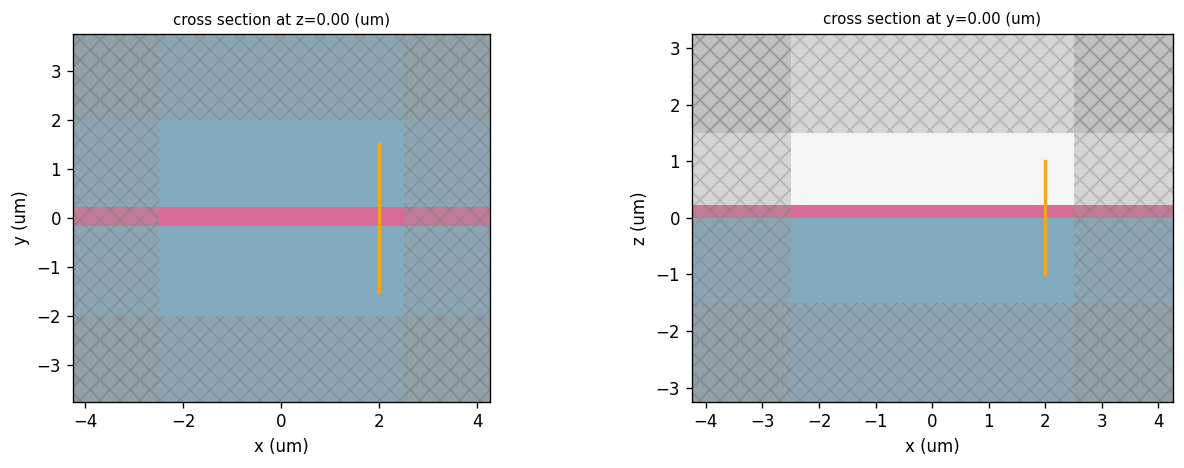

Selected source effective index: 2.2666
Mode effective indices: [2.26660891 1.57398031 1.44120918]


wavelength     n eff         k eff  loss (dB/cm)  \
f            mode_index                                                     
1.934145e+14 0                 1.55  2.266609  0.000000e+00  0.000000e+00   
             1                 1.55  1.573980  9.198762e-18  3.238858e-12   
             2                 1.55  1.441209  0.000000e+00  0.000000e+00   

                         TE (Ey) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.961771        0.659537        0.022437   
             1                   0.075320        0.075520        0.109844   
             2                   0.007246        0.055432        0.009056   

                         mode area  
f            mode_index             
1.934145e+14 0            0.149212  
             1            0.391556  
             2            1.879696

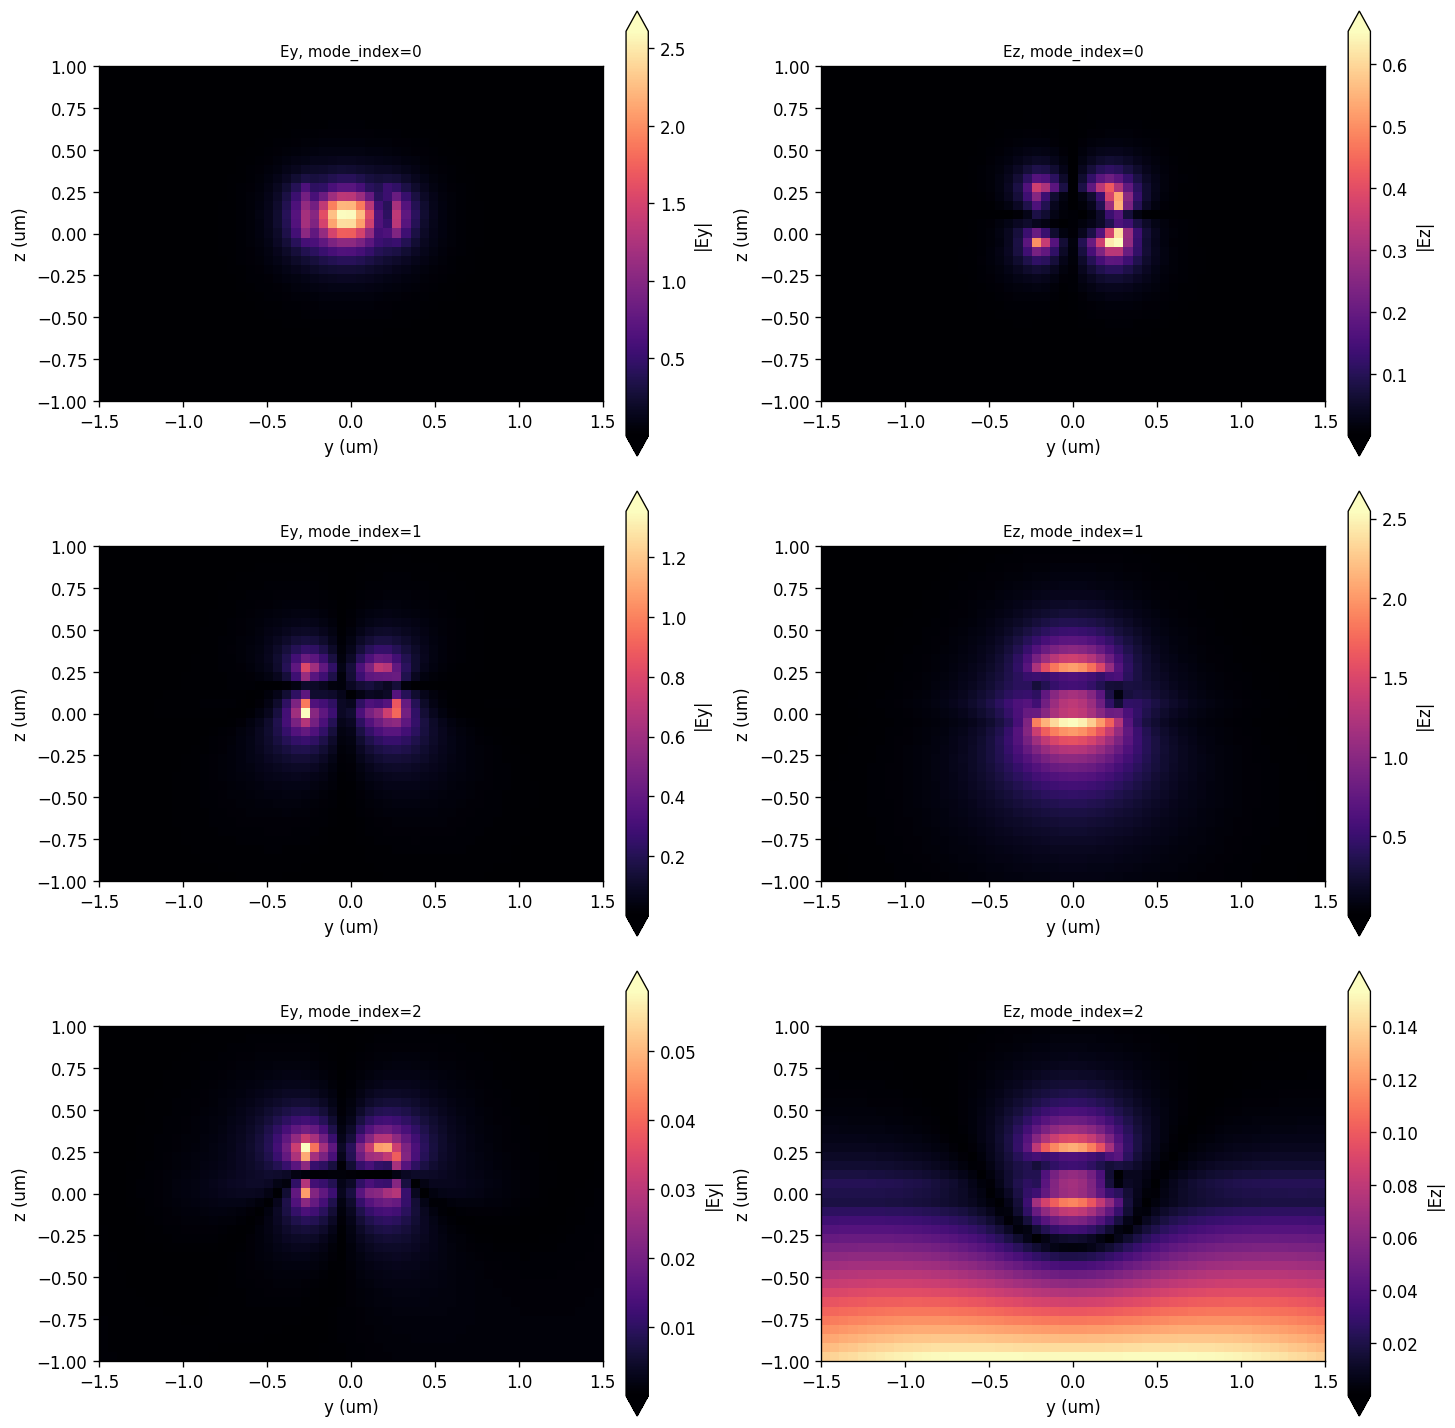

In [5]:
sim_preview, source_preview, monitors_preview, pulse_preview = build_simulation(design)
fig, axes = plot_setup(grid, source=False)
plt.show()

source_preview.initialize(grid.permittivity, DX, dt=DT)
print(f"Selected source effective index: {np.real(source_preview._neff):.4f}")

fig, axes, source_neffs = plot_source_modes(grid, num_modes=3)
print("Mode effective indices:", np.real(source_neffs))
source_mode_table = source_mode_dataframe(grid, num_modes=3)
display(source_mode_table)
plt.show()


## Run the Straight Waveguide

The run accumulates DFT fields on the source/reference and output planes. A separate in-plane DFT field monitor mirrors Tidy3D's `FieldMonitor` for the frequency-domain field plot.


In [6]:
RUN_SIMULATIONS = True

straight_result = None
if RUN_SIMULATIONS:
    sim_straight, source_straight, monitors_straight, pulse_straight = build_simulation(
        straight_waveguide_design(),
        source_profile_strategy=SOURCE_PROFILE_STRATEGY,
    )
    straight_run = sim_straight.run_compiled(
        progress=True,
        record_interval=max(1, sim_straight.num_steps // 80),
        record_fields=[FIELD_COMPONENT],
    )
    print(f"completed {sim_straight.current_step} FDTD steps")
    straight_result = compute_modal_dft_result(sim_straight, num_modes=3)
else:
    print("Set RUN_SIMULATIONS = True to run the local FDTD solve.")


● Done: Raster cache hit (3d): ae5cfa6843a4f5d0b8be3956eb12336213610e6329b0e397a95736112fa72372.npz | load=0.12s
● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (11826/11826 steps)
completed 11826 FDTD steps


## In-Plane Fields

The original Tidy3D notebook plots the real part of the frequency-domain `Ey` field from an in-plane `FieldMonitor`. Here we use the matching BEAMZ DFT field monitor on the horizontal plane through the waveguide center, displayed with the Tidy3D-equivalent `Ey` label for the selected BEAMZ guided branch.


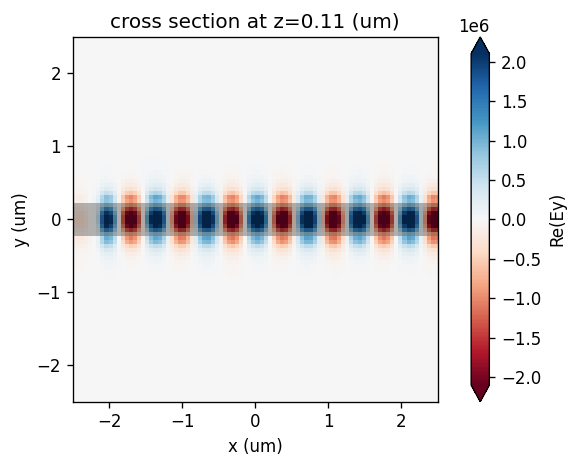

In [7]:
if RUN_SIMULATIONS:
    field_monitor_straight = next(m for m in sim_straight.monitors if m.name == "field")
    fig, ax = plot_tidy3d_dft_field(
        sim_straight,
        field_monitor_straight,
        field=FIELD_COMPONENT,
        display_field=DISPLAY_FIELD_COMPONENT,
        frequency=FREQ0,
        val="real",
        origin=plot_origin(),
        core_permittivity=SI_EPS,
        cmap="RdBu",
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
        show=False,
    )
    plt.show()


## Mode Monitor Decomposition

For the output monitor, BEAMZ solves local waveguide modes on the monitor cross-section and computes complex amplitudes for both propagation branches. The modal power in each branch is $|a|^2$ after normalization by the source port incident amplitude.


Flux at central frequency:  0.0016117716049000887
Power distribution at central frequency in first three modes
  positive dir.  [1.07126819e+00 1.45950188e-03 2.68790396e-06]
  negative dir.  [3.29472799e-05 1.70218338e-05 5.75789667e-07]


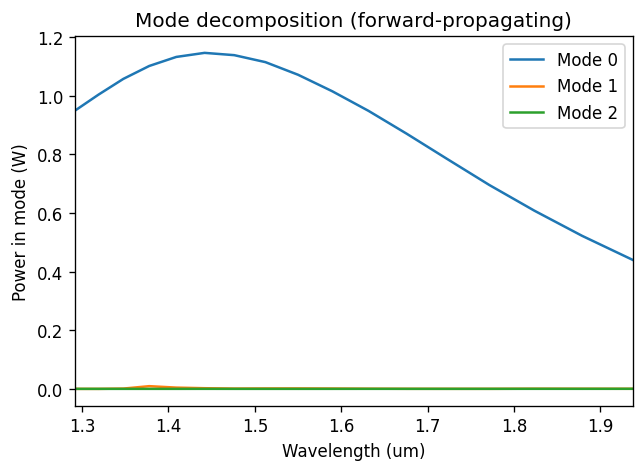

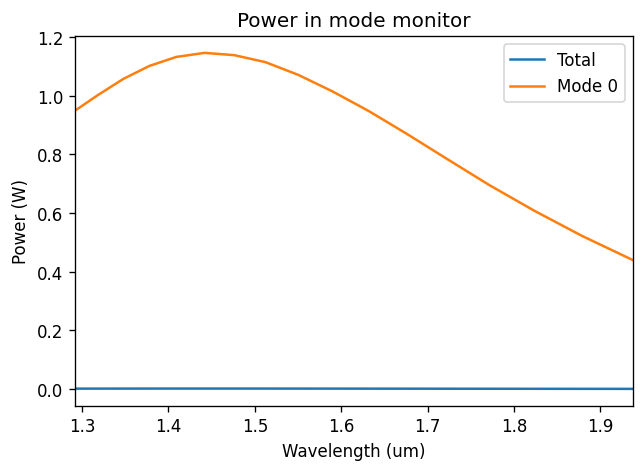

In [8]:
if RUN_SIMULATIONS:
    flux_wg = np.asarray(flux_monitor(monitors_straight, "out").get_dft_flux(), dtype=float)
    coeffs_f, coeffs_b = mode_coefficients(straight_result, num_modes=3)

    print("Flux at central frequency: ", flux_wg[FCENT_IND])
    print("Power distribution at central frequency in first three modes")
    print("  positive dir. ", np.abs(coeffs_f[FCENT_IND]) ** 2)
    print("  negative dir. ", np.abs(coeffs_b[FCENT_IND]) ** 2)

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, np.abs(coeffs_f) ** 2)
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Power in mode (W)")
    ax.set_title("Mode decomposition (forward-propagating)")
    ax.legend(["Mode 0", "Mode 1", "Mode 2"])
    plt.show()

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, flux_wg)
    ax.plot(LAMBDAS_UM, np.abs(coeffs_f[:, 0]) ** 2)
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Power (W)")
    ax.set_title("Power in mode monitor")
    ax.legend(["Total", "Mode 0"])
    plt.show()


## Waveguide Junction with Straight-Guide Normalization

Next we reproduce the Tidy3D width-step example by adding a wider silicon guide in the second half of the domain. The output guide is multimode, so the modal monitor quantifies how much power remains in the fundamental mode and how much transfers to higher-order modes.


● Done: Raster cache hit (3d): a2e723ebfb58583c8ea9482d3827f39052e6653766f92296c0b9079eabdb44e5.npz | load=0.10s


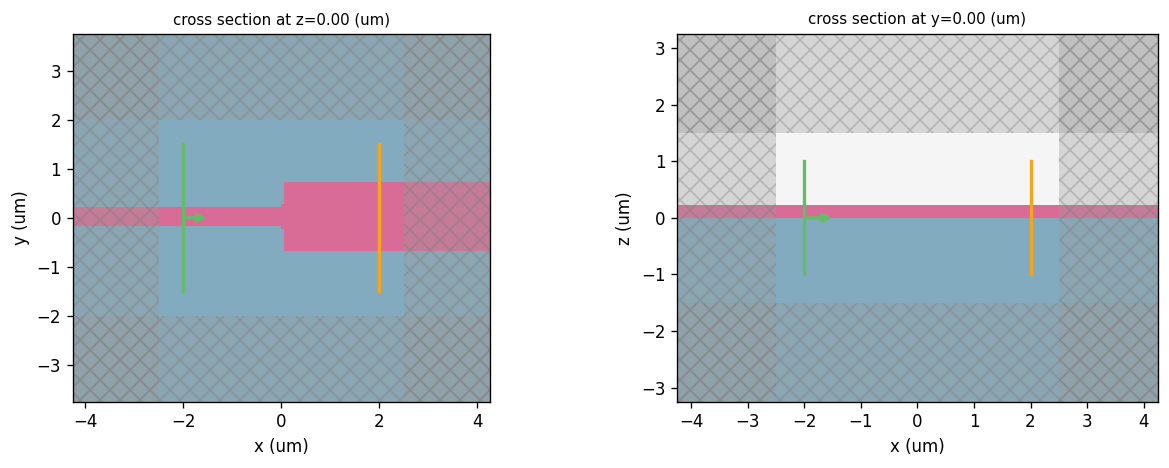

In [9]:
design_junction = junction_design(wgout_width=1.4 * µm)
grid_junction = design_junction.rasterize(resolution=DX)
fig, axes = plot_setup(grid_junction, junction=True, source=True)
plt.show()


In [10]:
junction_result = None
if RUN_SIMULATIONS:
    sim_jct, source_jct, monitors_jct, pulse_jct = build_simulation(
        design_junction,
        source_profile_strategy=SOURCE_PROFILE_STRATEGY,
    )
    junction_run = sim_jct.run_compiled(progress=True, record_fields=[])
    print(f"completed {sim_jct.current_step} FDTD steps")
    junction_result = compute_modal_dft_result(sim_jct, num_modes=3)


● JIT compiling v0.3 packed FDTD program... done!
● Progress: 100% (11826/11826 steps)
completed 11826 FDTD steps


## Junction In-Plane Fields

As in the straight-waveguide case, plot the real part of the frequency-domain in-plane field on the horizontal plane through the silicon core before decomposing the output into modes.


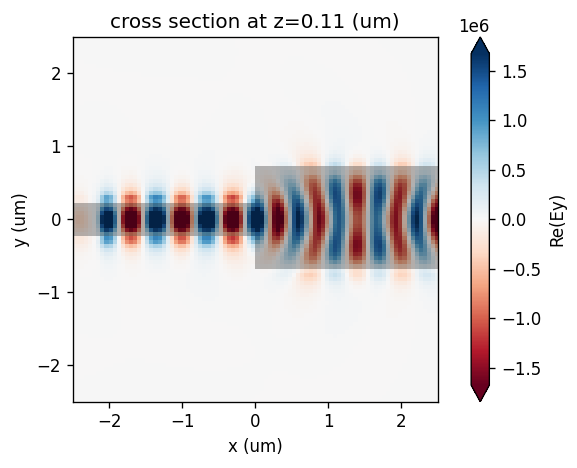

In [11]:
if RUN_SIMULATIONS:
    field_monitor_jct = next(m for m in sim_jct.monitors if m.name == "field")
    fig, ax = plot_tidy3d_dft_field(
        sim_jct,
        field_monitor_jct,
        field=FIELD_COMPONENT,
        display_field=DISPLAY_FIELD_COMPONENT,
        frequency=FREQ0,
        val="real",
        origin=plot_origin(),
        core_permittivity=SI_EPS,
        cmap="RdBu",
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
        show=False,
    )
    plt.show()


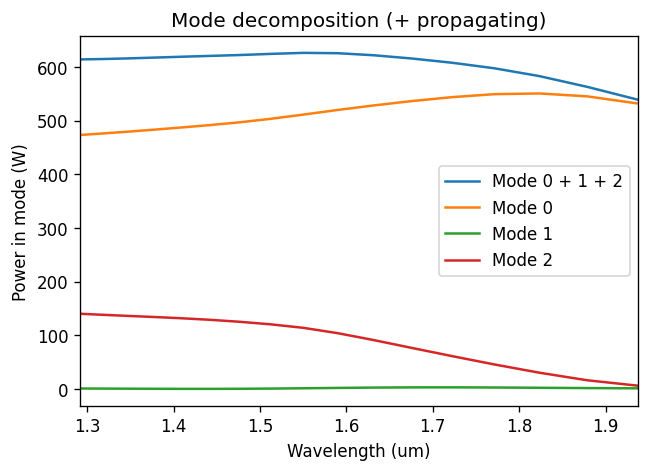

In [12]:
if RUN_SIMULATIONS:
    coeffs_f_jct, coeffs_b_jct = mode_coefficients(junction_result, num_modes=3)
    coeffs_f_jct = coeffs_f_jct / np.sqrt(np.maximum(flux_wg, 1e-18))[:, None]
    coeffs_b_jct = coeffs_b_jct / np.sqrt(np.maximum(flux_wg, 1e-18))[:, None]

    fig, ax = plt.subplots(1, figsize=(6, 4))
    ax.plot(LAMBDAS_UM, np.sum(np.abs(coeffs_f_jct) ** 2, axis=1))
    ax.plot(LAMBDAS_UM, np.abs(coeffs_f_jct) ** 2)
    ax.set_xlabel("Wavelength (um)")
    ax.set_xlim([LAMBDAS_UM[-1], LAMBDAS_UM[0]])
    ax.set_ylabel("Power in mode (W)")
    ax.set_title("Mode decomposition (+ propagating)")
    ax.legend(["Mode 0 + 1 + 2", "Mode 0", "Mode 1", "Mode 2"])
    plt.show()


## Summary

This notebook reproduces the core of the Tidy3D mode-source and mode-monitor example in BEAMZ:

1. Build a 3D silicon-on-silica straight waveguide.
2. Launch the fundamental guided mode with broadband `ModeSource` profiles.
3. Accumulate DFT fields on monitor planes.
4. Project those fields onto local waveguide modes with `PortSpec` and `get_S_matrix_modal_dft`.
5. Use a straight-waveguide normalization run to analyze mode conversion in a wider output waveguide.
